In [3]:
import numpy as np
from tensorflow.keras.datasets import mnist



In [8]:
# loading and preprocessing the data
train_images, train_labels = mnist.load_data()[0]
test_images, test_labels = mnist.load_data()[1]

X_train = (train_images.astype(np.float32) / 255.0).reshape(-1, 784)
X_test  = (test_images.astype(np.float32) / 255.0).reshape(-1, 784)



def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

def euclidean_distance(x, X_train):
    """
    x: shape (D,)
    X_train: shape (N, D)
    returns distances of shape (N,)
    """
    return np.sqrt(np.sum((X_train - x) ** 2, axis=1))


def knn_predict(X_train, y_train, X_test, k=3, num_classes=10):
    y_pred = []
    for x in X_test:
        # find distances from current test point to all training points
        distances = euclidean_distance(x, X_train)
        
        # sort distances and return indices of k nearest neighbors
        knn_indices = np.argpartition(distances, k-1)[:k]

        
        # find labels of k nearest neighbors
        knn_labels = y_train[knn_indices]
        # Voting
        counts = np.bincount(knn_labels, minlength=num_classes)
        y_pred.append(np.argmax(counts))
    return np.array(y_pred)

# Use a small subset first
N_train = 10000
N_test = 4000

Xtr = X_train[:N_train]
ytr = train_labels[:N_train]
Xte = X_test[:N_test]
yte = test_labels[:N_test]

for k in [1, 3, 5]:
    y_pred = knn_predict(Xtr, ytr, Xte, k=k)
    print(f"k={k}, accuracy={accuracy(yte, y_pred):.4f}")


k=1, accuracy=0.9243
k=3, accuracy=0.9247
k=5, accuracy=0.9213


Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 4.96MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 128kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 13.0MB/s]


Training on 60000 images, Testing on 10000 images

Starting k-NN loop...
k=1, Accuracy=0.9691
k=3, Accuracy=0.9705
k=5, Accuracy=0.9686
k=9, Accuracy=0.9665
k=15, Accuracy=0.9635
k=20, Accuracy=0.9623


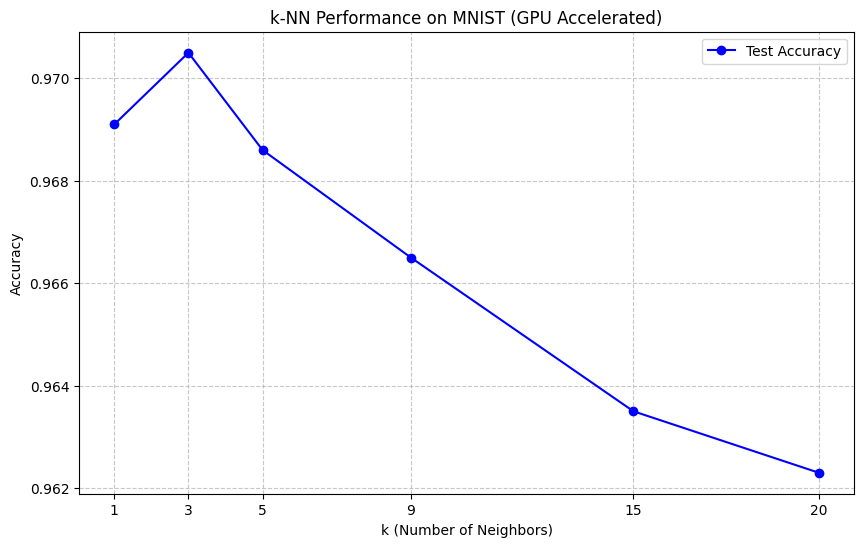

In [1]:
# GPU VERSION (quicker)
import torch
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

# 1. Setup Device (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Efficient Data Loading (using PyTorch standard loaders)
# We load the full dataset to demonstrate GPU power
transform = transforms.Compose([transforms.ToTensor()])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# Move data to GPU immediately and flatten
# Shape: (N, 784)
X_train = train_dataset.data.float().reshape(-1, 784).to(device) / 255.0
y_train = train_dataset.targets.to(device)

X_test = test_dataset.data.float().reshape(-1, 784).to(device) / 255.0
y_test = test_dataset.targets.to(device)

print(f"Training on {len(X_train)} images, Testing on {len(X_test)} images")

def knn_predict_batched(X_train, y_train, X_test, k=3, batch_size=1000):
    """
    Performs k-NN on GPU using batches to manage memory.
    """
    num_test = X_test.shape[0]
    y_pred = torch.empty(num_test, dtype=torch.long, device=device)

    # Process test set in batches
    for i in range(0, num_test, batch_size):
        end = min(i + batch_size, num_test)
        X_test_batch = X_test[i:end]
        
        # 1. Compute distances using optimized torch.cdist
        # This calculates Euclidean distance between every test point in batch and ALL train points
        # Shape: (Batch_Size, N_Train)
        dists = torch.cdist(X_test_batch, X_train)
        
        # 2. Get the k smallest distances
        # largest=False returns smallest elements
        # Shape: (Batch_Size, k)
        _, indices = dists.topk(k, dim=1, largest=False)
        
        # 3. Get labels of neighbors
        neighbor_labels = y_train[indices]
        
        # 4. Voting (Mode)
        # torch.mode returns (values, indices), we take values [0]
        batch_preds, _ = torch.mode(neighbor_labels, dim=1)
        y_pred[i:end] = batch_preds
        
    return y_pred

# --- Running the Experiment ---

k_values = [1, 3, 5, 9, 15, 20]
accuracies = []

print("\nStarting k-NN loop...")
for k in k_values:
    # Run prediction
    y_pred = knn_predict_batched(X_train, y_train, X_test, k=k, batch_size=2000)
    
    # Calculate accuracy on GPU
    acc = (y_pred == y_test).float().mean().item()
    accuracies.append(acc)
    print(f"k={k}, Accuracy={acc:.4f}")

# --- Plotting Results ---

plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linestyle='-', color='b', label='Test Accuracy')
plt.title('k-NN Performance on MNIST (GPU Accelerated)')
plt.xlabel('k (Number of Neighbors)')
plt.ylabel('Accuracy')
plt.xticks(k_values)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()